In [40]:
## Import Modules
import matplotlib.pyplot as plt
import numpy as np

## Fluid Domain
a=5
b=5

## Mesh grid
x=np.linspace(-a,a,200)
y=np.linspace(-b,b,200)
X,Y=np.meshgrid(x,y)

U=1 ## flow velocity
R=1.5 ## cylinder radius
rho=1.2
r=np.sqrt(X**2 + Y**2)
theta=np.arctan(Y/X)

## Velocity components in Polar coordinates
Vr=U*(1-(R/r)**2)*np.cos(theta)
Vt=-U*(1+(R/r)**2)*np.sin(theta)

## Velocity components in Cartesian Coordinates
Vx=Vr*np.cos(theta) - Vt*np.sin(theta)
Vy=Vr*np.sin(theta) + Vt*np.cos(theta)
Vx[r<R]=np.nan
Vy[r<R]=np.nan

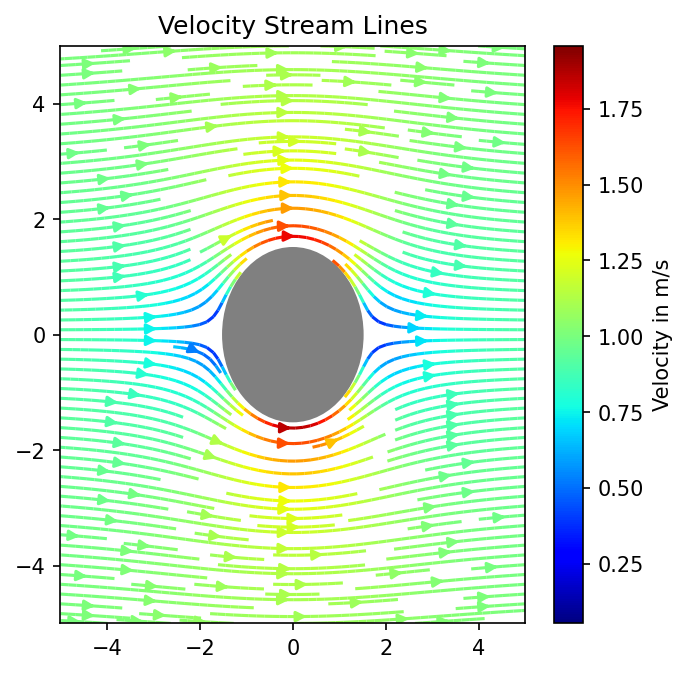

In [41]:
## Plot the stream lines
fig1=plt.figure(figsize=(5,5),dpi=150)
ax1=fig1.add_subplot()
circle1=plt.Circle((0,0),R,color="grey")
plt.gca().add_patch(circle1)
velocity_lines=plt.streamplot(X,Y,Vx,Vy,color=(Vx**2+Vy**2)**0.5,cmap="jet",density=[2,2])
cbar=plt.colorbar(velocity_lines.lines)
cbar.set_label("Velocity in m/s")
plt.title("Velocity Stream Lines")
plt.show()

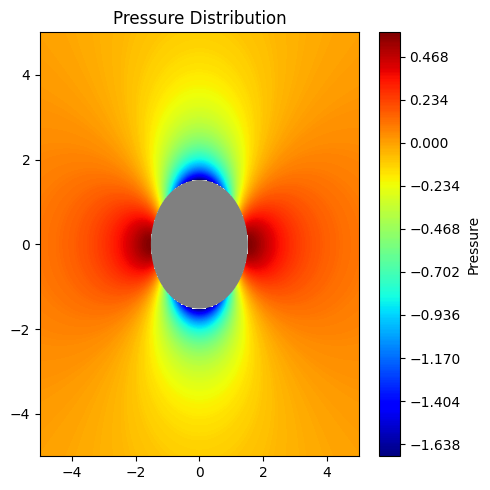

In [42]:
## Compute and plot Pressure
P=(0.5)*(rho)*(U**2)*((2*((R/r)**2)*((np.cos(theta))**2-(np.sin(theta))**2)) - ((R/r)**4))
P[r<R]=np.nan
fig2=plt.figure(figsize=(5,5),dpi=100)
ax2=fig2.add_subplot()
pressure=plt.contourf(X,Y,P,levels=400,cmap="jet")
circle2=plt.Circle((0,0),R,color="grey")
plt.gca().add_patch(circle2)
cbar2=plt.colorbar(pressure)
cbar2.set_label("Pressure")
plt.title("Pressure Distribution")
plt.tight_layout()
plt.show()